## **Financial Fraud Detection Exploratory Data Analysis**

insert abstract similar to main README file

**DON'T FORGET TO REMOVE DF SAMPLE AND REPLACE WITH DF**

---
### **1. Imports**

In [1]:
# Importing sys to ensure proper environment setup
import sys

!{sys.executable} -m pip install lightgbm

print(sys.version_info)

sys.version_info(major=3, minor=11, micro=14, releaselevel='final', serial=0)


In [2]:
# Importing pandas and numpy for numerical analysis
# Importing pyplot and seaborn to visualize the data
# Importing lightgbm as gradient boosting framework for tree based learning algorightms
# Importing os, pathlib, and warnings for functionality, faster loading, flagging exceptions, etc.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import ticker
import seaborn as sns
import lightgbm as lgb
import os # possibly remove
from pathlib import Path
from scipy.stats import trim_mean
import warnings
warnings.filterwarnings('ignore')

# Importing sklearn items for model training & testing
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    precision_recall_curve, precision_score, classification_report,
    confusion_matrix, accuracy_score, recall_score, f1_score, 
    roc_curve, roc_auc_score, precision_recall_fscore_support)

# Makes graphs appear in line
%matplotlib inline

sns.set(style="whitegrid", palette="muted", font_scale=1.25)

print("Setup Complete")

Setup Complete


---
### **2. Data Loading & Preliminary Exploration**

In [3]:
# Dealing with plathform-specific issues that may cause errors
# For systems that use backslash (\) characters instead of forward (/) slash
from pathlib import Path, PureWindowsPath

# Explicity noting path as being in Windows format so I can use forward slash
filename = PureWindowsPath("C:\\Users\\Winni\\Downloads\\PS_2017_log.csv")

# Convert path to the correct format
file_path = Path(filename)

# Loading data as a DataFrame
df = pd.read_csv(file_path) 

# Using head() function to display the first five rows of the data
print("Heads")
print(df.head())

print()

# Using tail() function to display the last five rows of the data
print("Tails")
print(df.tail())

Heads
   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0        0               0  

Tails
         step      type      amount     nameOrig  oldbalanceOrg  \
6362615   743  CASH_OUT  

In [4]:
# Using shape() function to return a tuple listing number of rows and columns in the DataFrame. 
print("Shape:", df.shape)

Shape: (6362620, 11)


In [5]:
# Using info() function to view column names, data types, and other relevant information.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


#### **<p style="text-align:center;">Column Descriptions</p>**
● **Step:** A unit of time that represents hours in the dataset. Think of this as the timestamp of the transaction (e.g. hour 1, hour 2, … hour 534, …) <br>
● **Type:** The type of transaction <br>
● **Amount:** The amount of money transferred <br>
● **NameOrig:** The origin account name <br>
● **OldBalanceOrg:** The origin accounts balance before the transaction <br> 
● **NewBalanceOrg:** The origin accounts balance after the transaction <br>
● **NameDest:** The destination account name <br>
● **OldbalanceDest:** The destination accounts balance before the transaction <br> 
● **NewbalanceDest:** The destination accounts balance after the transaction <br>
● **IsFlaggedFraud:** A “naive” model that simply flags a transaction as fraudulent if it is greater than 200,000 (note that this currency is not USD) <br>
● **IsFraud:** Was this simulated transaction actually fraudulent? In this case, we consider “fraud” to be a malicious transaction that aimed to transfer funds out of a victim’s bank account before the account owner could secure their information. <br>

In [6]:
# Using describe() function and rounding output as two decimal points.
# Output is basic descriptive and statistics for each column.

df.describe().round(2)

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6362620.00,6362620.00,6362620.00,6362620.00,6.362620e+06,6.362620e+06,6362620.00,6362620.0
mean,243.40,179861.90,833883.10,855113.67,1.100702e+06,1.224996e+06,0.00,0.0
std,142.33,603858.23,2888242.67,2924048.50,3.399180e+06,3.674129e+06,0.04,0.0
min,1.00,0.00,0.00,0.00,0.000000e+00,0.000000e+00,0.00,0.0
25%,156.00,13389.57,0.00,0.00,0.000000e+00,0.000000e+00,0.00,0.0
50%,239.00,74871.94,14208.00,0.00,1.327057e+05,2.146614e+05,0.00,0.0
75%,335.00,208721.48,107315.18,144258.41,9.430367e+05,1.111909e+06,0.00,0.0
max,743.00,92445516.64,59585040.37,49585040.37,3.560159e+08,3.561793e+08,1.00,1.0


---
### **3.    Initial Visualizations**

In [7]:
# Sample 15% of data used to ensure visualizations worked
sr = df.sample(frac=0.15)

# Verify number of rows
print(f"Original rows: {len(df)}")
print(f"Samples rows (15%): {len(df)}")

# Displaying result
sr

Original rows: 6362620
Samples rows (15%): 6362620


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
1421010,139,CASH_IN,181475.91,C233384270,2313984.44,2495460.35,C687247176,3286791.46,3105315.55,0,0
5944368,405,PAYMENT,13576.81,C470557589,518378.64,504801.83,M940070757,0.00,0.00,0,0
2388345,201,CASH_OUT,4225.19,C958411096,0.00,0.00,C1375119612,292950.37,297175.55,0,0
1451327,140,CASH_IN,111399.08,C665098067,2600877.09,2712276.16,C879565060,1262513.46,1151114.38,0,0
346943,16,CASH_IN,62336.75,C1815799398,9032218.00,9094554.75,C1574777168,2535391.51,2473054.76,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6306863,684,CASH_OUT,200295.55,C808368788,24267.00,0.00,C1804154174,0.00,200295.55,0,0
4684702,331,CASH_IN,179966.23,C1301531704,333347.17,513313.40,C650334478,1809157.27,1629191.04,0,0
6038166,478,PAYMENT,20241.78,C1595893570,0.00,0.00,M579590392,0.00,0.00,0,0
531852,20,PAYMENT,2821.43,C1903063471,7932.00,5110.57,M1420827598,0.00,0.00,0,0


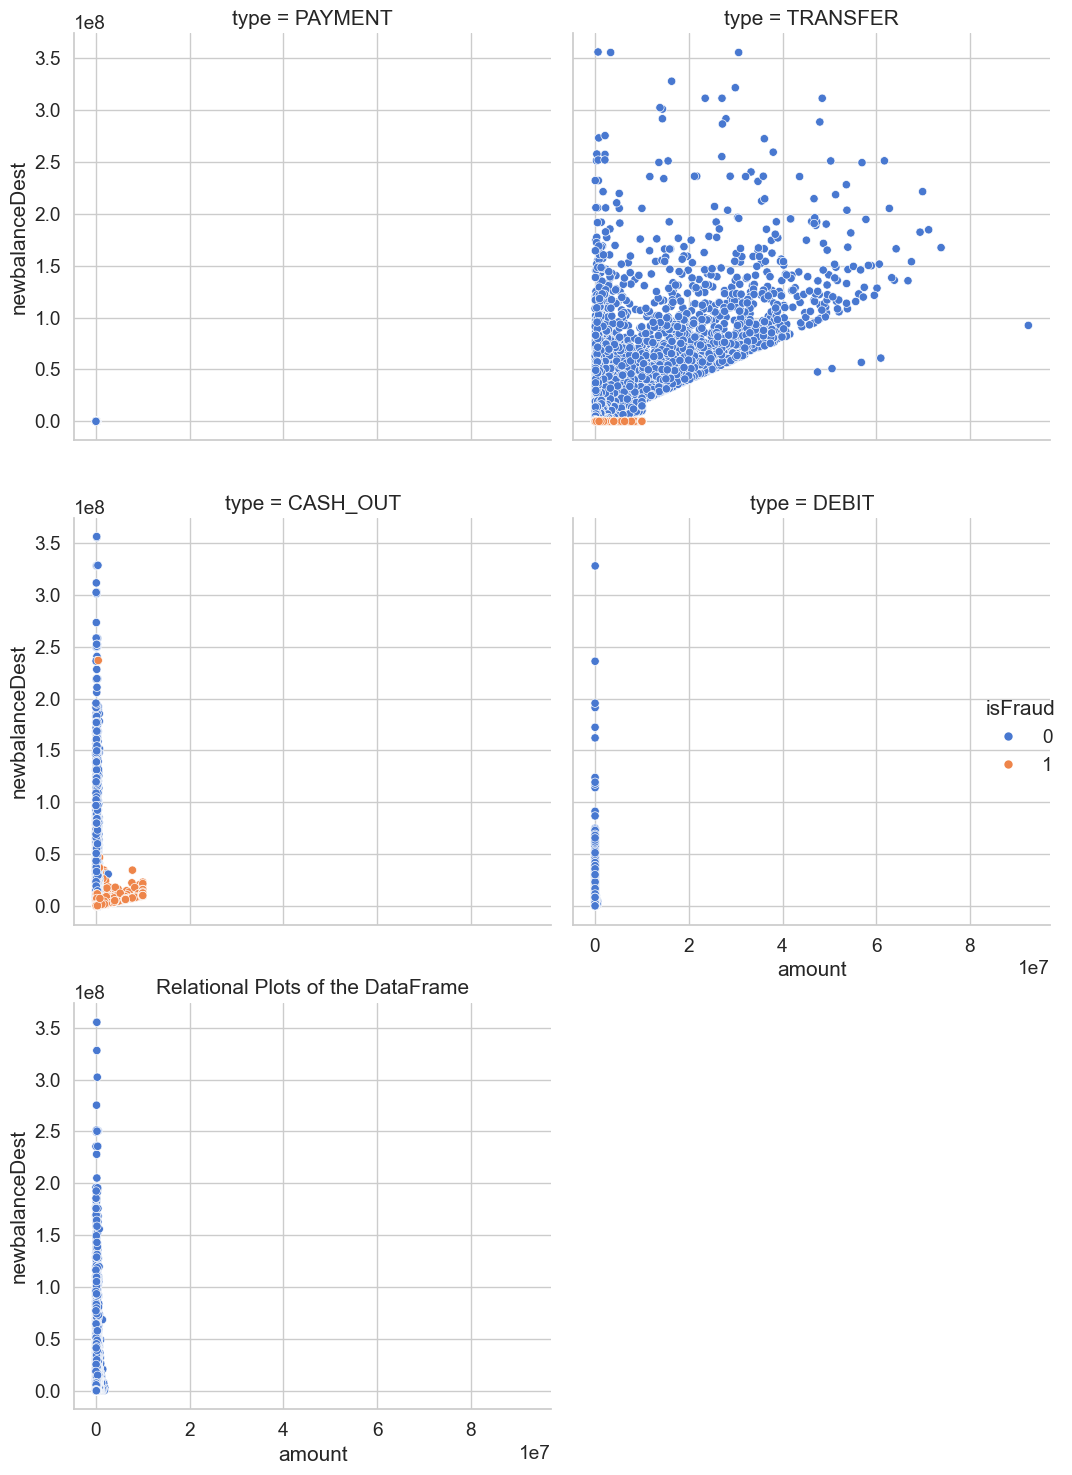

In [8]:
# Relational plot to begin visualizing the data

sns.relplot(data=df, x='amount', y='newbalanceDest', hue='isFraud', col='type', col_wrap=2)
plt.title("Relational Plots of the DataFrame")
plt.tight_layout()
plt.show()

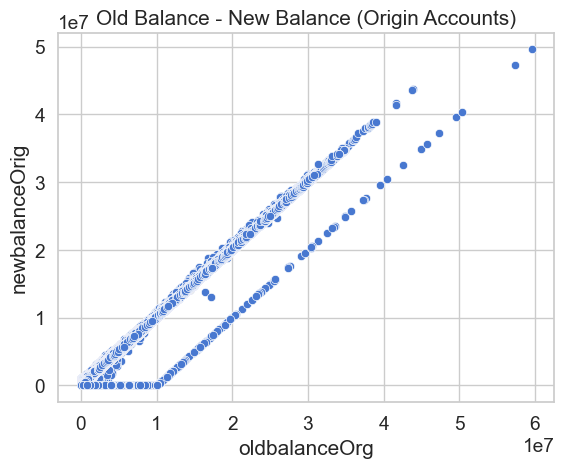

In [9]:
# Scatterplot of originating accounts

sns.scatterplot(x=df['oldbalanceOrg'], y=df['newbalanceOrig'])
plt.title("Old Balance - New Balance (Origin Accounts)")
plt.show()

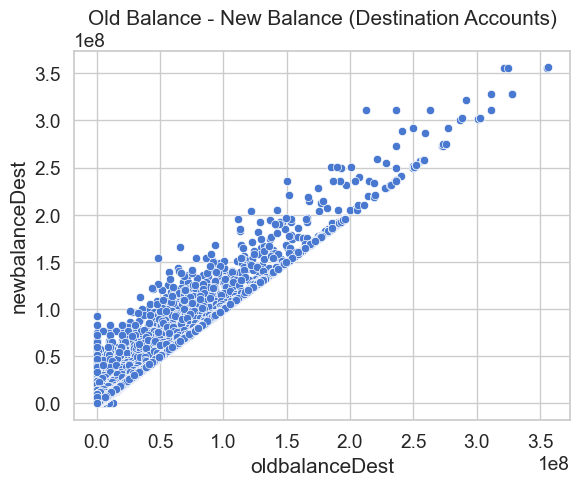

In [10]:
# Scatterplot of destination accounts

sns.scatterplot(x=df['oldbalanceDest'], y=df['newbalanceDest'])
plt.title("Old Balance - New Balance (Destination Accounts)")
plt.show()

#### **<p style="text-align:center;">Initial Insights</p>**
● **Step:** A unit of time that represents hours in the dataset. Think of this as the timestamp of the transaction (e.g. hour 1, hour 2, … hour 534, …) <br>
● **Type:** The type of transaction <br>
● **Amount:** The amount of money transferred <br>
● **NameOrig:** The origin account name <br>
● **OldBalanceOrg:** The origin accounts balance before the transaction <br> 
● **NewBalanceOrg:** The origin account

---
### **4. Correlations & Heatmaps**

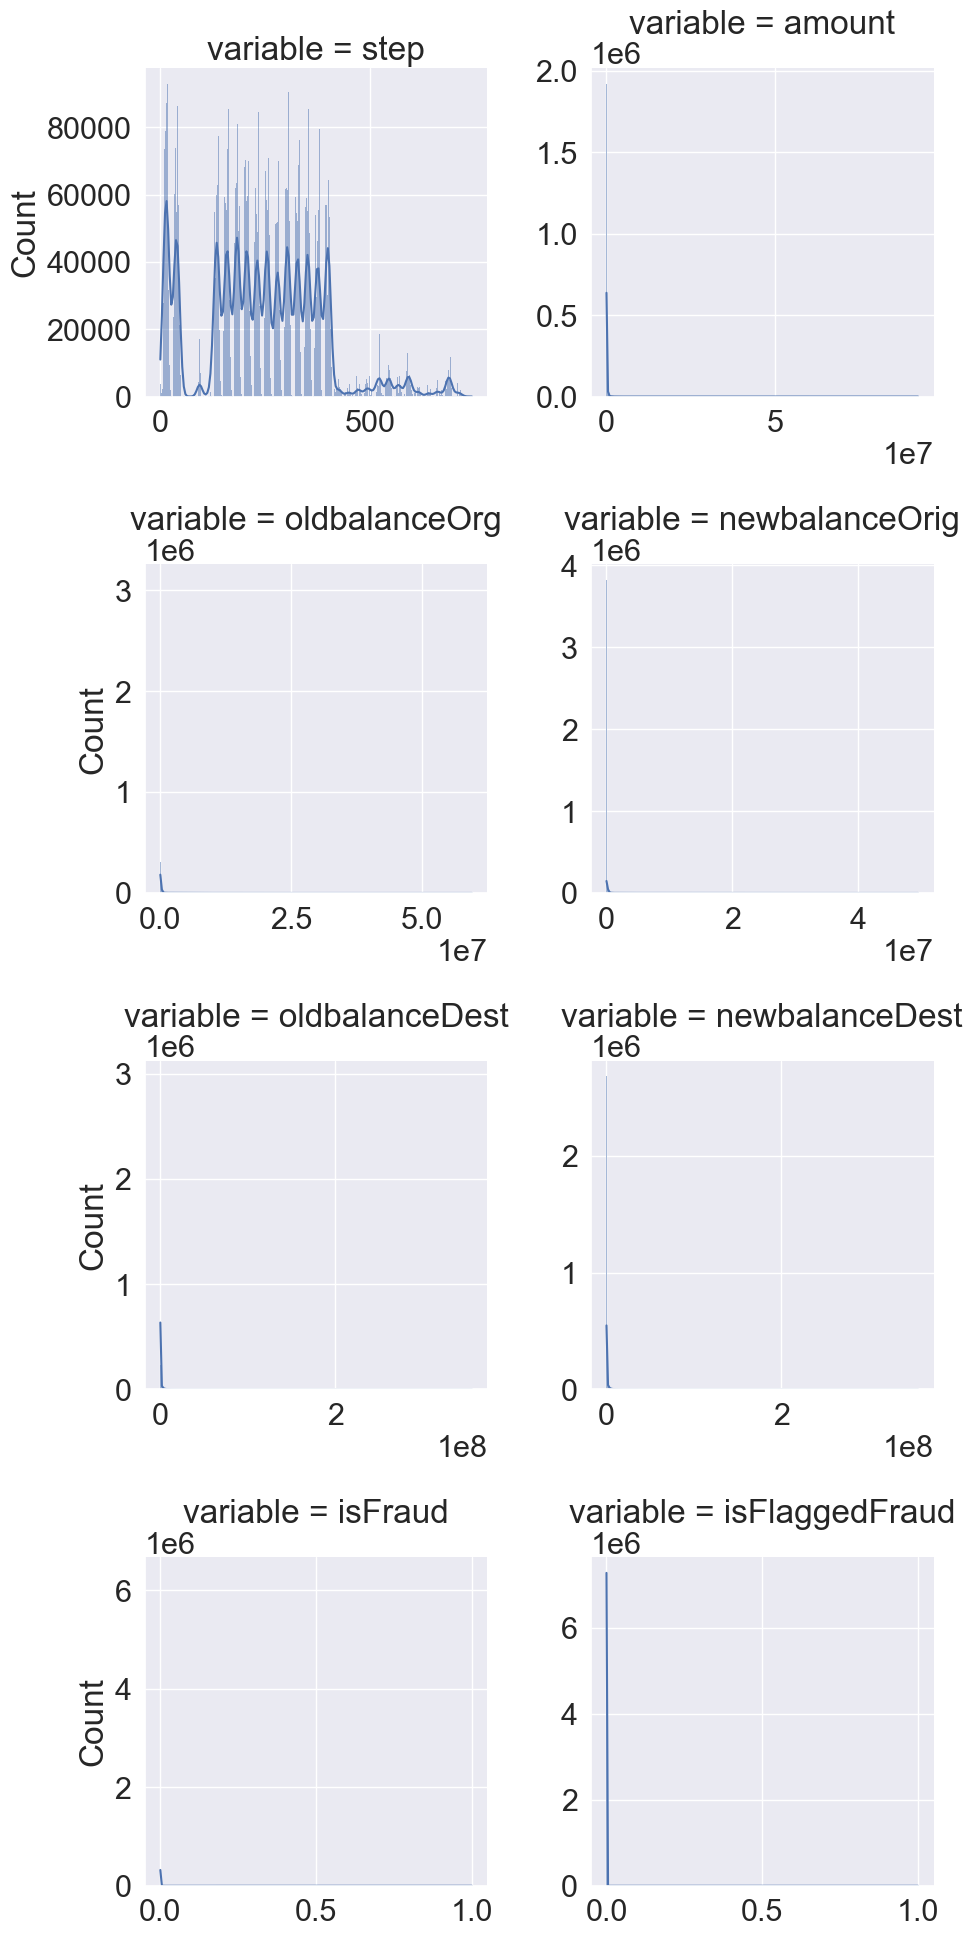

In [11]:
# Pair plot to get preliminary comparisons

plt.rcParams['font.size'] = 16
sns.set(font_scale=2)

compare_columns = df.select_dtypes(exclude=['object']).columns
df_long = df.melt(value_vars=compare_columns)
g = sns.displot(data=df_long, kde=True, x='value', common_bins=False, col='variable', col_wrap=2,
                facet_kws={'sharex': False, 'sharey': False})
g.set(xlabel='')
plt.show()

In [12]:
# Finding initial relationships between columns
corr = df.corr(numeric_only=True).round(4)
print(corr)

                  step  amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  \
step            1.0000  0.0224        -0.0101         -0.0103          0.0277   
amount          0.0224  1.0000        -0.0028         -0.0079          0.2941   
oldbalanceOrg  -0.0101 -0.0028         1.0000          0.9988          0.0662   
newbalanceOrig -0.0103 -0.0079         0.9988          1.0000          0.0678   
oldbalanceDest  0.0277  0.2941         0.0662          0.0678          1.0000   
newbalanceDest  0.0259  0.4593         0.0420          0.0418          0.9766   
isFraud         0.0316  0.0767         0.0102         -0.0081         -0.0059   
isFlaggedFraud  0.0033  0.0123         0.0038          0.0038         -0.0005   

                newbalanceDest  isFraud  isFlaggedFraud  
step                    0.0259   0.0316          0.0033  
amount                  0.4593   0.0767          0.0123  
oldbalanceOrg           0.0420   0.0102          0.0038  
newbalanceOrig          0.0418  -0.008

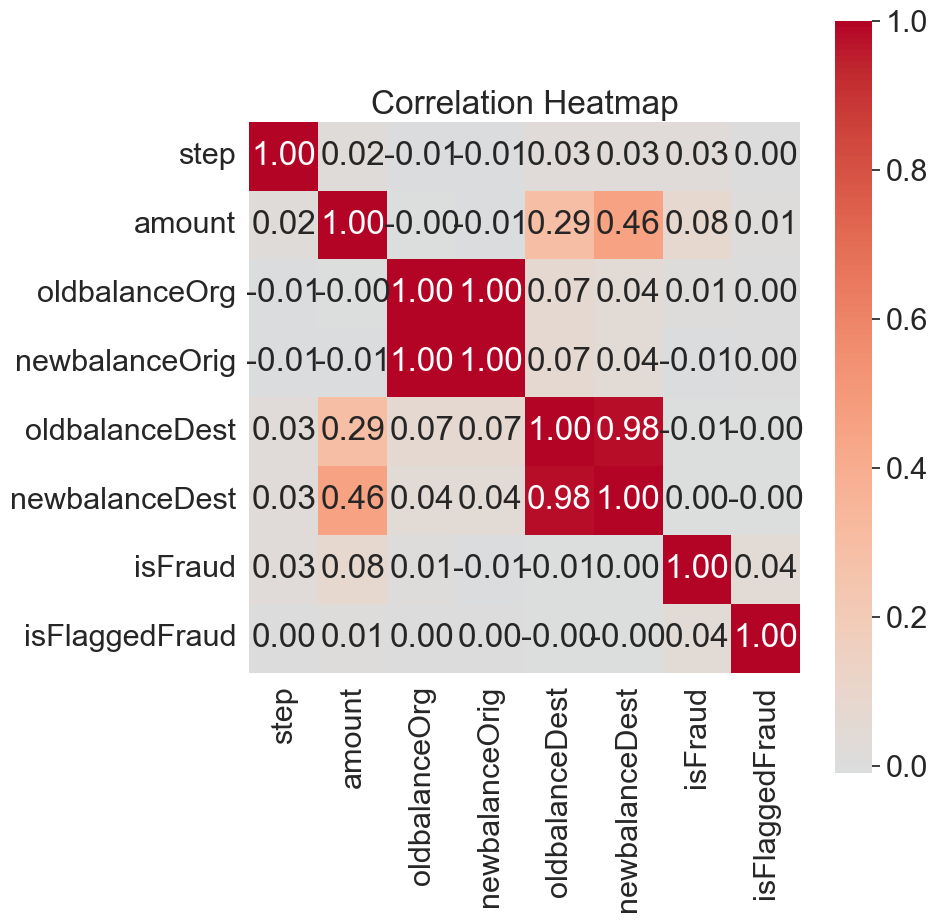

In [13]:
# Visualization of correlations using heatmap
plt.figure(figsize=(10,10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Correlation Scatterplot')

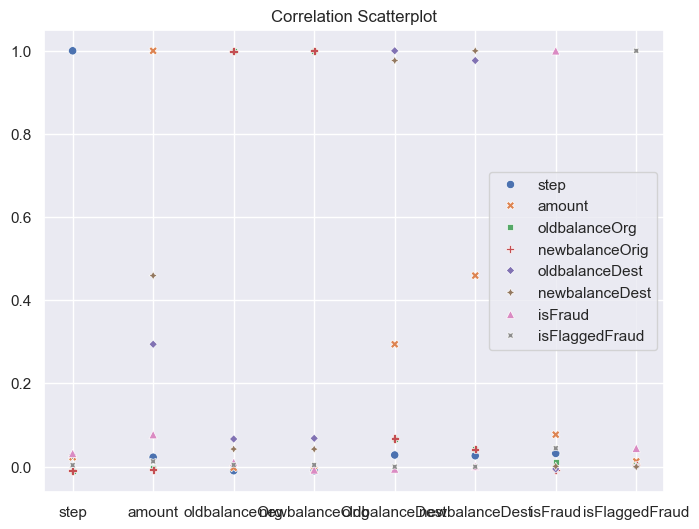

In [14]:
# Scatterplot of correlations
sns.set(rc={"figure.figsize":(8,6)}) 

sns.scatterplot(corr)
plt.title("Correlation Scatterplot")

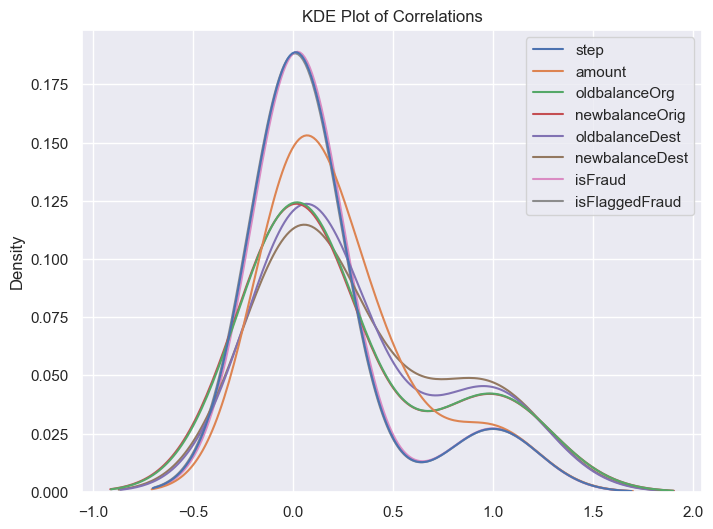

In [15]:
# KDE plot of correlations
sns.set(rc={"figure.figsize":(8,6)})

sns.kdeplot(corr)
plt.title("KDE Plot of Correlations")
plt.show()

#### **<p style="text-align:center;">Heatmap Hot or Cold Feedback</p>**
● **Step:** A unit of time that represents hours in the dataset. Think of this as the timestamp of the transaction (e.g. hour 1, hour 2, … hour 534, …) <br>
● **Type:** The type of transaction <br>
● **Amount:** The amount of money transferred <br>
● **NameOrig:** The origin account name <br>
● **OldBalanceOrg:** The origin accounts balance before the transaction <br> 
● **NewBalanceOrg:** The origin account

---
### **5. Amounts, Fraud & Flagged Fraud: Analysis & Visualizations**

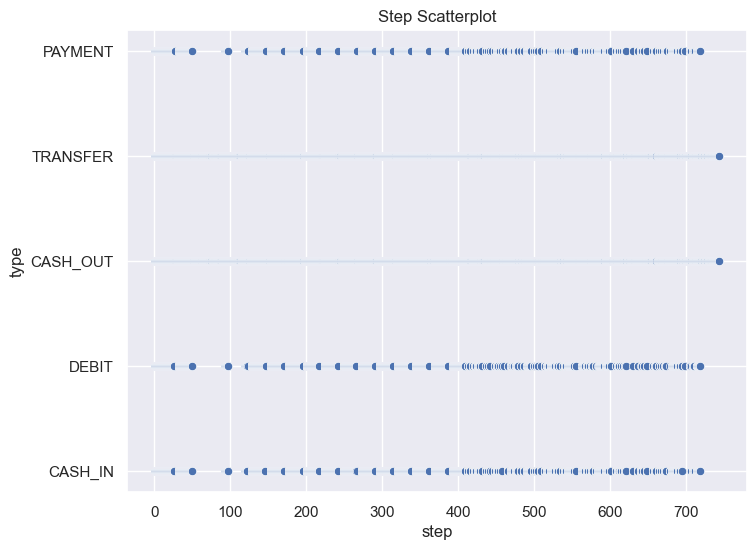

In [16]:
# Scatterplot of 'step'
sns.scatterplot(x='step', y='type', data=df)
plt.title('Step Scatterplot')
plt.show()

Zero amount fraud transactions: 16
Zero amount non-fraud transactions: 0
Zero amount flagged fraud transactions: 0


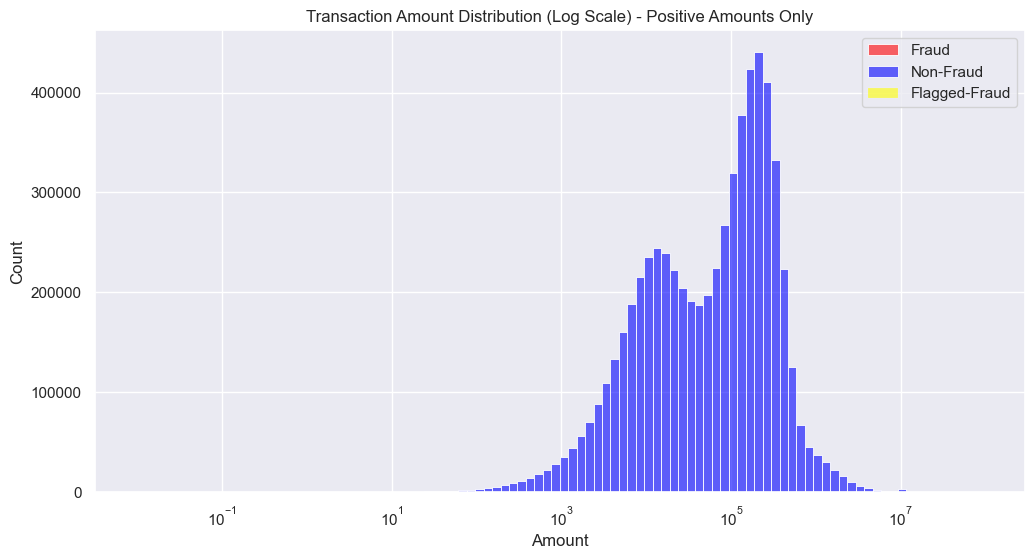

Excluded 16 zero-amount transactions


In [17]:
# Amounts Analysis

# Checking for zero values
zero_fraud = (df['isFraud']==1) & (df['amount'] == 0)
zero_non_fraud = (df['isFraud']==0) & (df['amount'] == 0)
zero_flfraud = (df['isFlaggedFraud']==1) & (df['amount'] == 0)

print(f"Zero amount fraud transactions: {zero_fraud.sum()}")
print(f"Zero amount non-fraud transactions: {zero_non_fraud.sum()}")
print(f"Zero amount flagged fraud transactions: {zero_flfraud.sum()}")

# Filtering plots
plt.figure(figsize=(12,6))
fraud_data = df[(df['isFraud']==1) & (df['amount'] > 0)]
non_fraud_data = df[(df['isFraud']==0) & (df['amount'] > 0)]
flfraud_data = df[(df['isFlaggedFraud']==1) & (df['amount'] > 0)]

sns.histplot(fraud_data['amount'], bins=100, color="red", label="Fraud", alpha=0.6, log_scale=True)
sns.histplot(non_fraud_data['amount'], bins=100, color="blue", label="Non-Fraud", alpha=0.6, log_scale=True)
sns.histplot(flfraud_data['amount'], bins=100, color="yellow", label="Flagged-Fraud", alpha=0.6, log_scale=True)
plt.legend()
plt.title("Transaction Amount Distribution (Log Scale) - Positive Amounts Only")
plt.xlabel("Amount")
plt.show()

print(f"Excluded {zero_fraud.sum() + zero_non_fraud.sum()} zero-amount transactions")

isFraud
0    0.998709
1    0.001291
Name: proportion, dtype: float64


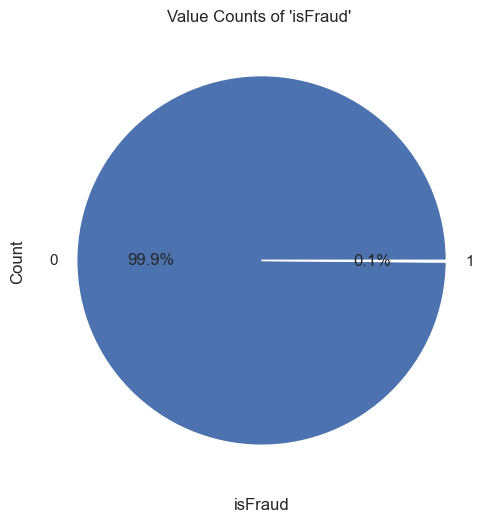

In [18]:
# Looking at 'isFraud' counts
fraud_counts = df['isFraud'].value_counts(normalize=True)
print(fraud_counts)

# Plotting value counts as pie chart with matplotlib
fraud_counts.plot(kind='pie', autopct='%1.1f%%')
plt.xlabel('isFraud')
plt.ylabel('Count')
plt.title("Value Counts of 'isFraud' ")
plt.show()

isFlaggedFraud
0    0.999997
1    0.000003
Name: proportion, dtype: float64


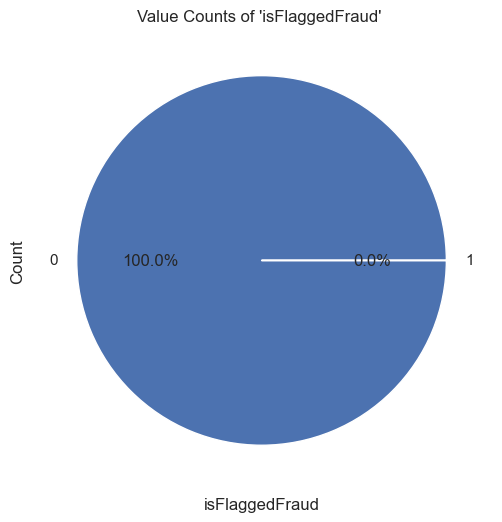

In [19]:
# Looking at 'isFlaggedFraud' counts
flagfraud_counts = df['isFlaggedFraud'].value_counts(normalize=True)
print(flagfraud_counts)

# Plotting value counts as pie chart with matplotlib
flagfraud_counts.plot(kind='pie', autopct='%1.1f%%')
plt.xlabel('isFlaggedFraud')
plt.ylabel('Count')
plt.title("Value Counts of 'isFlaggedFraud' ")
plt.show()

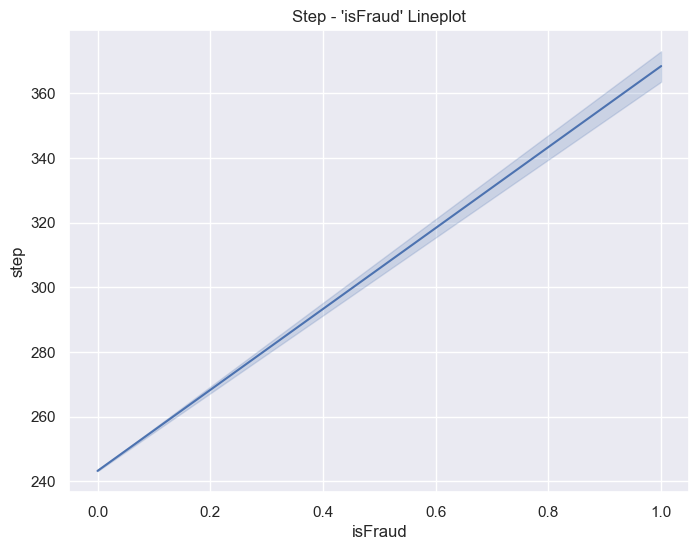

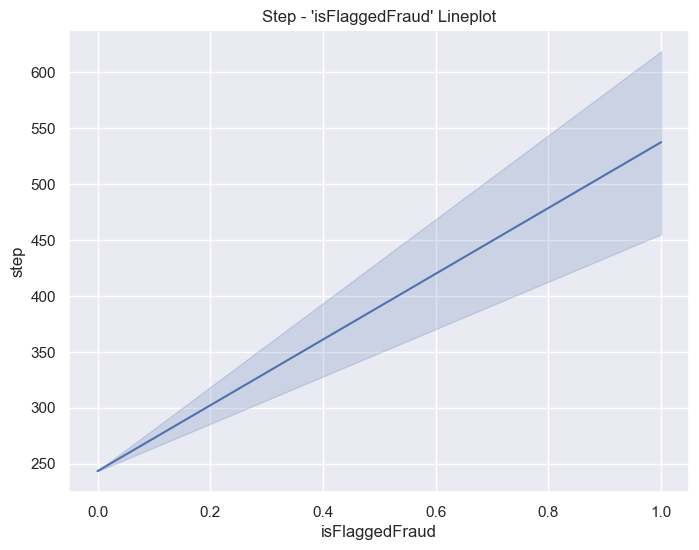

In [20]:
# Line Plots of step by fraud type

sns.lineplot(df, x = 'isFraud', y = 'step')
plt.title("Step - 'isFraud' Lineplot")
plt.show()

sns.lineplot(df, x = 'isFlaggedFraud', y = 'step')
plt.title("Step - 'isFlaggedFraud' Lineplot")
plt.show()

type
TRANSFER    0.007688
CASH_OUT    0.001840
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64


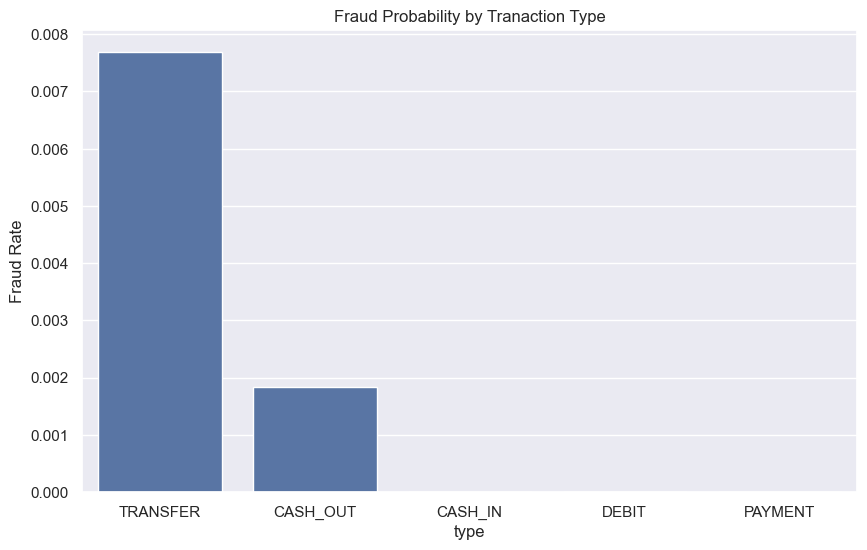

In [21]:
# 'isFraud' by Transaction Type
fraud_by_type = df.groupby("type")["isFraud"].mean().sort_values(ascending=False)
print(fraud_by_type)

# Utilizing barplot
plt.figure(figsize=(10,6))
sns.barplot(x=fraud_by_type.index, y=fraud_by_type.values)
plt.title("Fraud Probability by Tranaction Type")
plt.ylabel("Fraud Rate")
plt.show()

type
TRANSFER    0.00003
CASH_IN     0.00000
CASH_OUT    0.00000
DEBIT       0.00000
PAYMENT     0.00000
Name: isFlaggedFraud, dtype: float64


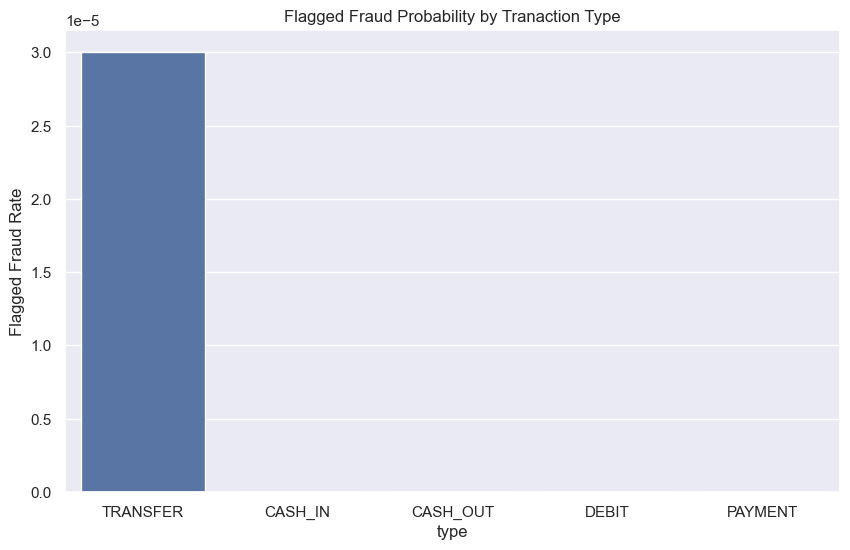

In [22]:
# 'isFlaggedFraud' by Transaction Type
flagfraud_by_type = df.groupby("type")["isFlaggedFraud"].mean().sort_values(ascending=False)
print(flagfraud_by_type)

# Utilizing barplot
plt.figure(figsize=(10,6))
sns.barplot(x=flagfraud_by_type.index, y=flagfraud_by_type.values)
plt.title("Flagged Fraud Probability by Tranaction Type")
plt.ylabel("Flagged Fraud Rate")
plt.show()

(0.0, 300000.0)

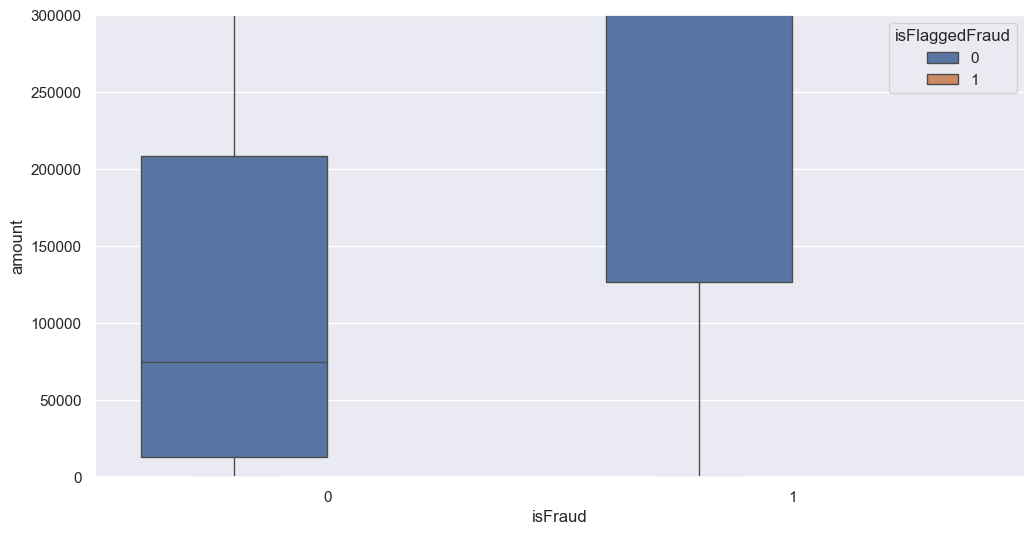

In [23]:
# Boxplot comparing fraud types
plt.figure(figsize=(12,6))
sns.boxplot(x="isFraud", y="amount", hue="isFlaggedFraud", data=df)
plt.ylim(0, 300000)     # Flag threshold

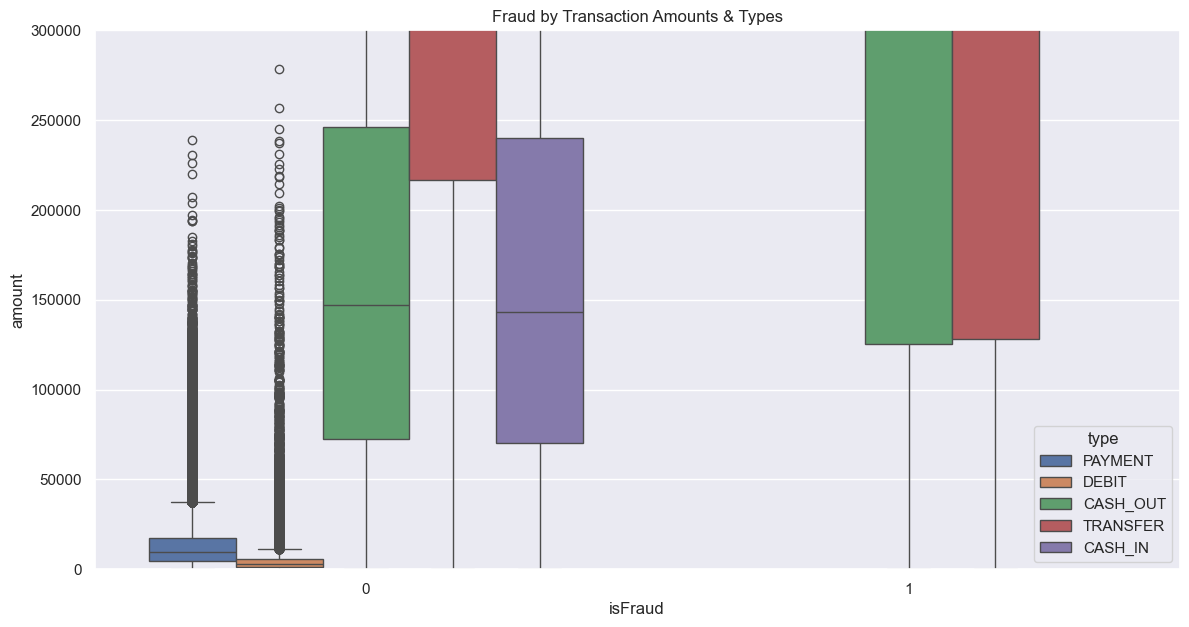

In [24]:
# 'isFraud' boxplot for comparison
plt.figure(figsize=(14,7))
sns.boxplot(x='isFraud', y='amount', hue='type', data=df)
plt.ylim(0, 300000)    # Flag threshold
plt.title("Fraud by Transaction Amounts & Types")
plt.show()

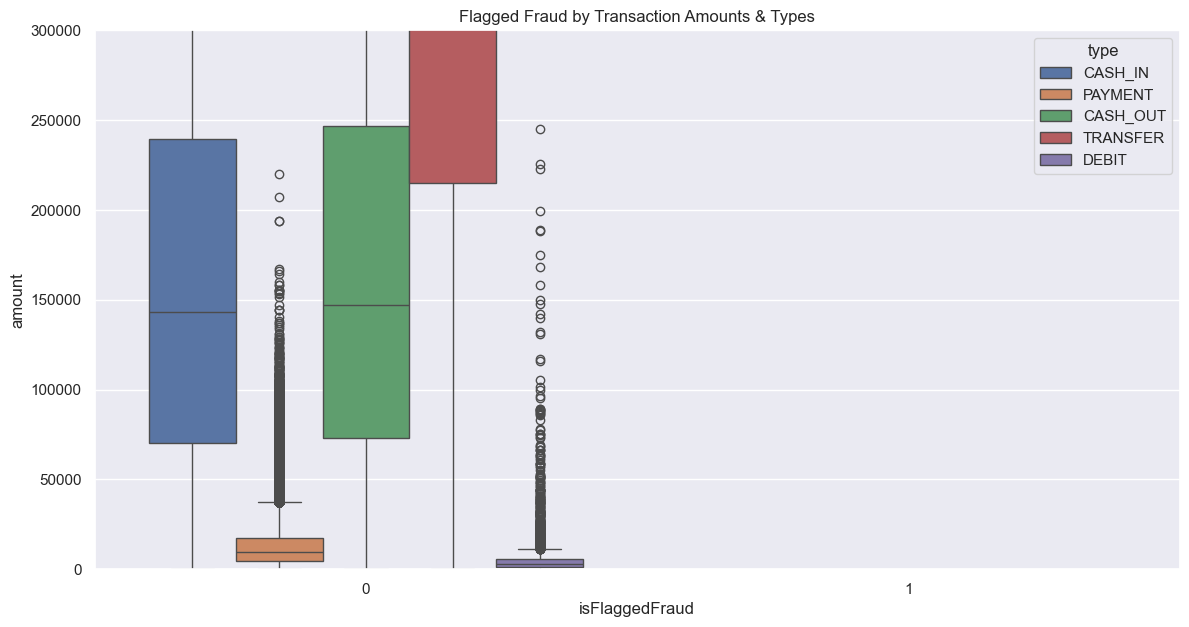

In [25]:
# 'isFlaggedFraud' boxplot for comparison
plt.figure(figsize=(14,7))
sns.boxplot(x='isFlaggedFraud', y='amount', hue='type', data=sr)
plt.ylim(0, 300000)    # Flag threshold
plt.title("Flagged Fraud by Transaction Amounts & Types")
plt.show()

Transfer & Cash Out only:
              type     amount     nameOrig     nameDest  isFraud  \
2388345  CASH_OUT    4225.19   C958411096  C1375119612        0   
5563851  CASH_OUT  150149.04   C217967117   C359623589        0   
5529668  CASH_OUT  252360.91  C1178872793   C633966839        0   
1258732  CASH_OUT  323760.20   C986839763   C584614964        0   
5362111  CASH_OUT  268948.09  C2094412174   C401495233        0   

         isFlaggedFraud  
2388345               0  
5563851               0  
5529668               0  
1258732               0  
5362111               0  
<class 'pandas.core.frame.DataFrame'>


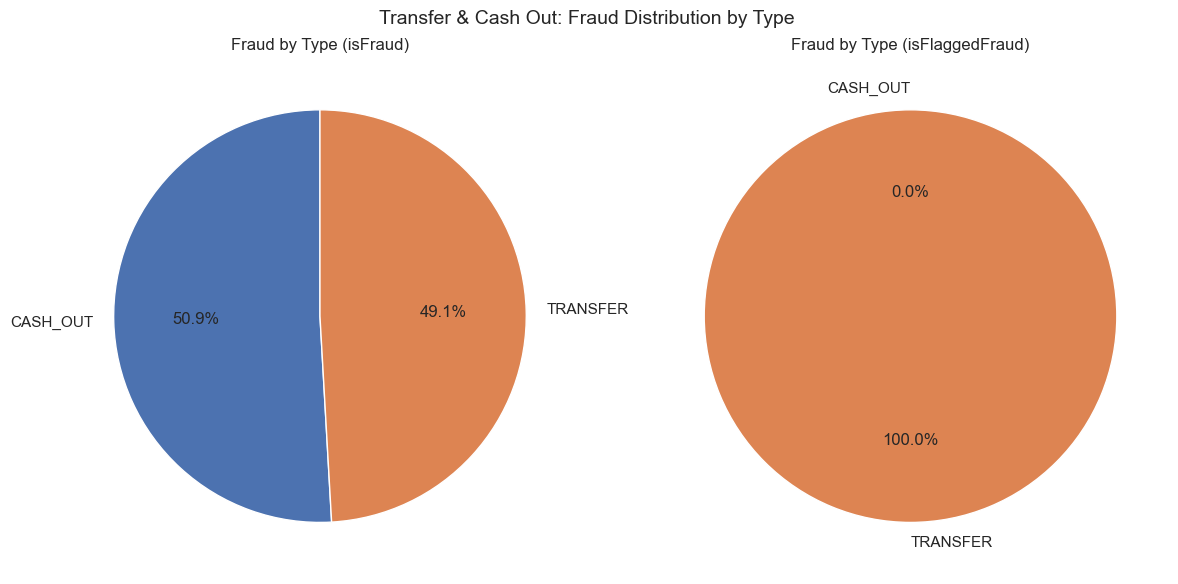

In [26]:
# Creating DataFrame of 'isFraud' boolean indexing by 'type'
fraudgrp_df = sr[sr['type'].isin(['TRANSFER', 'CASH_OUT'])][[
    'type','amount', 'nameOrig', 'nameDest', 'isFraud', 'isFlaggedFraud']].copy()

# Grouping by 'type' for 'isFraud' and 'isFlaggedFraud' separately
fraud_grouped = fraudgrp_df.groupby('type')[['isFraud', 'isFlaggedFraud']].sum().reset_index()

# View new DataFrame info & check type
print("Transfer & Cash Out only:\n", fraudgrp_df.head())
print(type(fraudgrp_df))

# Creating side-by-side pie charts
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Pie chart for isFraud
axes[0].pie(fraud_grouped['isFraud'], labels=fraud_grouped['type'],
            autopct='%1.1f%%', startangle=90)
axes[0].set_title("Fraud by Type (isFraud)")

# Pie chart for isFlaggedFraud
axes[1].pie(fraud_grouped['isFlaggedFraud'], labels=fraud_grouped['type'],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title("Fraud by Type (isFlaggedFraud)")

plt.suptitle("Transfer & Cash Out: Fraud Distribution by Type", fontsize=14)
plt.tight_layout()
plt.show()

#### **<p style="text-align:center;">Fraud v Flagged Fraud Feedback</p>**
● **Step:** A unit of time that represents hours in the dataset. Think of this as the timestamp of the transaction (e.g. hour 1, hour 2, … hour 534, …) <br>
● **Type:** The type of transaction <br>
● **Amount:** The amount of money transferred <br>
● **NameOrig:** The origin account name <br>
● **OldBalanceOrg:** The origin accounts balance before the transaction <br> 
● **NewBalanceOrg:** The origin account

---
### **6.  Multivariate Analysis**

In [27]:
# Top fraud originating accounts
top_fraud_orig = (fraudgrp_df[fraudgrp_df['isFraud'] == 1]['nameOrig']
              .value_counts()
              .head(10)
              .reset_index())
top_fraud_orig.columns = ['nameOrig', 'fraud_count']

# Top fraud receiver accounts
top_fraud_dest = (fraudgrp_df[fraudgrp_df['isFraud'] == 1]['nameDest']
                  .value_counts()
                  .head(10)
                  .reset_index())
top_fraud_dest.columns = ['nameDest', 'fraud_count']

print("Top Fraud Originators:\n", top_fraud_orig)
print("\nTop Fraud Destinations:\n", top_fraud_dest)

Top Fraud Originators:
       nameOrig  fraud_count
0  C1481880227            1
1   C383746092            1
2  C1053675722            1
3  C1168747121            1
4   C366677925            1
5    C31108995            1
6  C1879175902            1
7  C1103494239            1
8  C1205919663            1
9  C1641368956            1

Top Fraud Destinations:
       nameDest  fraud_count
0   C104038589            2
1  C1460854172            2
2   C794646915            1
3   C503599136            1
4  C1191561711            1
5  C1433310823            1
6  C1800726477            1
7   C971866524            1
8  C1783581377            1
9  C1881116283            1


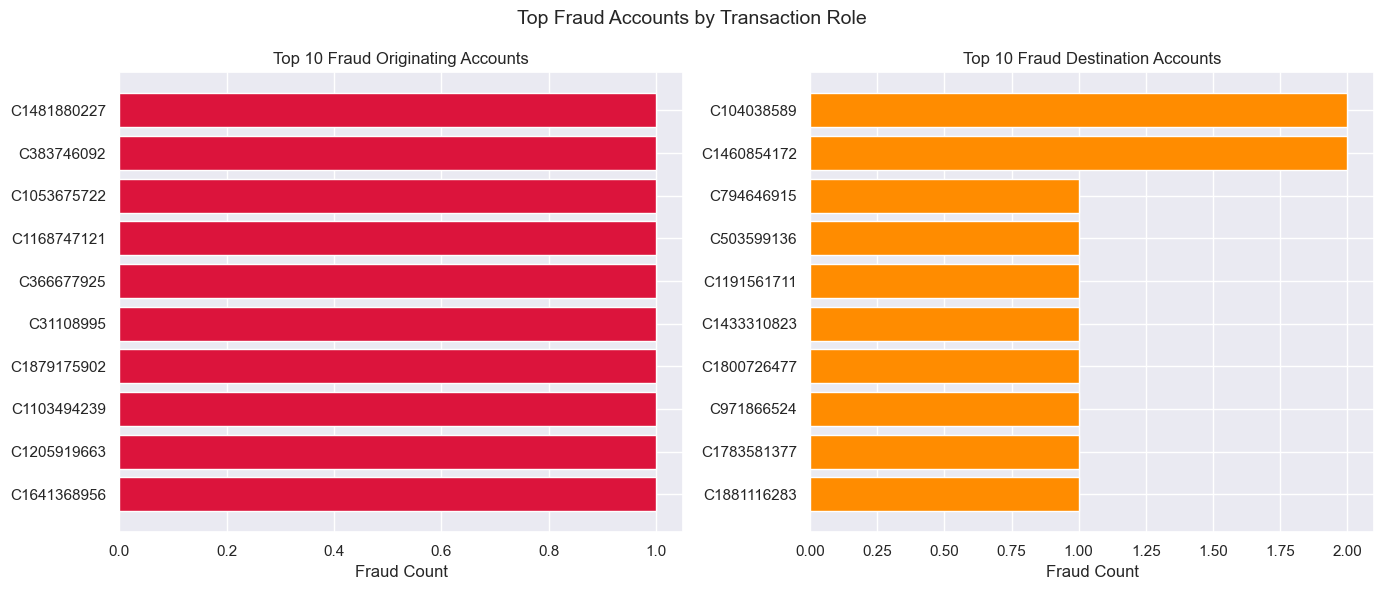

In [28]:
# Visual top fraud accounts with a bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top sender accounts
axes[0].barh(top_fraud_orig['nameOrig'], top_fraud_orig['fraud_count'], color='crimson')
axes[0].set_title('Top 10 Fraud Originating Accounts')
axes[0].set_xlabel('Fraud Count')
axes[0].invert_yaxis()

# Top receiver accounts
axes[1].barh(top_fraud_dest['nameDest'], top_fraud_dest['fraud_count'], color='darkorange')
axes[1].set_title('Top 10 Fraud Destination Accounts')
axes[1].set_xlabel('Fraud Count')
axes[1].invert_yaxis()

plt.suptitle('Top Fraud Accounts by Transaction Role', fontsize=14)
plt.tight_layout()
plt.show()

### ***EDA: Hypothesis Produced*** 
The transaction types that are consistently noted as fraud are 'TRANSFER' at ##% and 'CASH_OUT' at ##%. As such, consideration to dropping the other types for the model since this already such a large dataset.